# 🧠 Binary Pattern Learning Using a Boltzmann Machine
### Academic Project: Energy-Based Neural Networks & Associative Memory
---

**Author:** Academic Project  
**Domain:** Machine Learning / Generative Models / Associative Memory  
**Key Concepts:** Restricted Boltzmann Machine (RBM), Contrastive Divergence (CD-1), Gibbs Sampling, Energy Minimization, Pattern Denoising  

---

## 📌 1. Project Overview & Theoretical Background

A **Restricted Boltzmann Machine (RBM)** is a two-layer, bipartite, undirected graphical energy-based model consisting of:
1. **Visible Layer ($v \in \{0, 1\}^V$):** Represents observable inputs (in our case, 25 binary pixels of a $5 \times 5$ image grid).
2. **Hidden Layer ($h \in \{0, 1\}^H$):** Latent feature detectors capturing correlations and high-order statistical regularities.

Because there are **no intra-layer connections** (i.e., visible units do not connect to visible units, and hidden units do not connect to hidden units), the hidden units are conditionally independent given the visible units, and vice-versa.

### 📐 Mathematical Formulation

#### 1. Energy Function:
$$E(v, h) = - \sum_{i=1}^{V} a_i v_i - \sum_{j=1}^{H} b_j h_j - \sum_{i=1}^{V} \sum_{j=1}^{H} v_i W_{ij} h_j = - v^T W h - a^T v - b^T h$$

Where:
- $W \in \mathbb{R}^{V \times H}$ is the symmetric weight matrix.
- $a \in \mathbb{R}^V$ is the visible bias vector.
- $b \in \mathbb{R}^H$ is the hidden bias vector.

#### 2. Conditional Probability Distributions:
$$P(h_j = 1 \mid v) = \sigma\left(b_j + \sum_{i=1}^V v_i W_{ij}\right)$$
$$P(v_i = 1 \mid h) = \sigma\left(a_i + \sum_{j=1}^H h_j W_{ij}\right)$$
where $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the logistic sigmoid function.

#### 3. Free Energy:
$$F(v) = - \ln \sum_h e^{-E(v, h)} = - v^T a - \sum_{j=1}^H \ln\left(1 + e^{b_j + v W_j}\right)$$

#### 4. Contrastive Divergence (CD-1):
Instead of running Gibbs sampling to thermal equilibrium (which is computationally intractable), **Contrastive Divergence ($k=1$)** approximates the log-likelihood gradient using 1 full Gibbs step:
$$\Delta W = \eta \left( \langle v^{(0)} h^{(0)T} \rangle_{\text{data}} - \langle v^{(1)} h^{(1)T} \rangle_{\text{model}} \right) - \lambda W + \gamma \Delta W_{\text{prev}}$$


## 🛠️ Step 1: Environment Setup & Library Imports

In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Set random seed for exact reproducibility
np.random.seed(42)

# Configure Matplotlib styling
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.edgecolor': '#cbd5e1',
    'axes.linewidth': 1.2,
    'grid.color': '#f1f5f9',
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#ffffff',
    'figure.dpi': 120
})

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")


NumPy version: 1.26.4
Pandas version: 3.0.0
Matplotlib version: 3.10.8


## 📊 Step 2: Dataset Ingestion & Exploratory Analysis

In [2]:
# Locate dataset relative to notebook or project root
dataset_path = os.path.join('..', 'dataset', 'binary_patterns_dataset.csv')
if not os.path.exists(dataset_path):
    dataset_path = 'binary_patterns_dataset.csv'

df = pd.read_csv(dataset_path)
pixel_cols = [c for c in df.columns if c.startswith('pixel_')]
X = df[pixel_cols].values.astype(np.float64)
y = df['pattern'].values

print("Dataset Summary:")
print(f"• Total Samples: {len(df)}")
print(f"• Number of Features (Pixels): {len(pixel_cols)} (5x5 grid)")
print(f"• Unique Pattern Classes: {df['pattern'].nunique()}")
print("\nSamples per Class:")
print(df['pattern'].value_counts())


Dataset Summary:
• Total Samples: 400
• Number of Features (Pixels): 25 (5x5 grid)
• Unique Pattern Classes: 8

Samples per Class:
pattern
X          50
PLUS       50
SQUARE     50
T          50
L          50
DIAMOND    50
H_LINE     50
V_LINE     50
Name: count, dtype: int64


## 🎨 Step 3: Extract & Visualize Canonical Ground-Truth Patterns

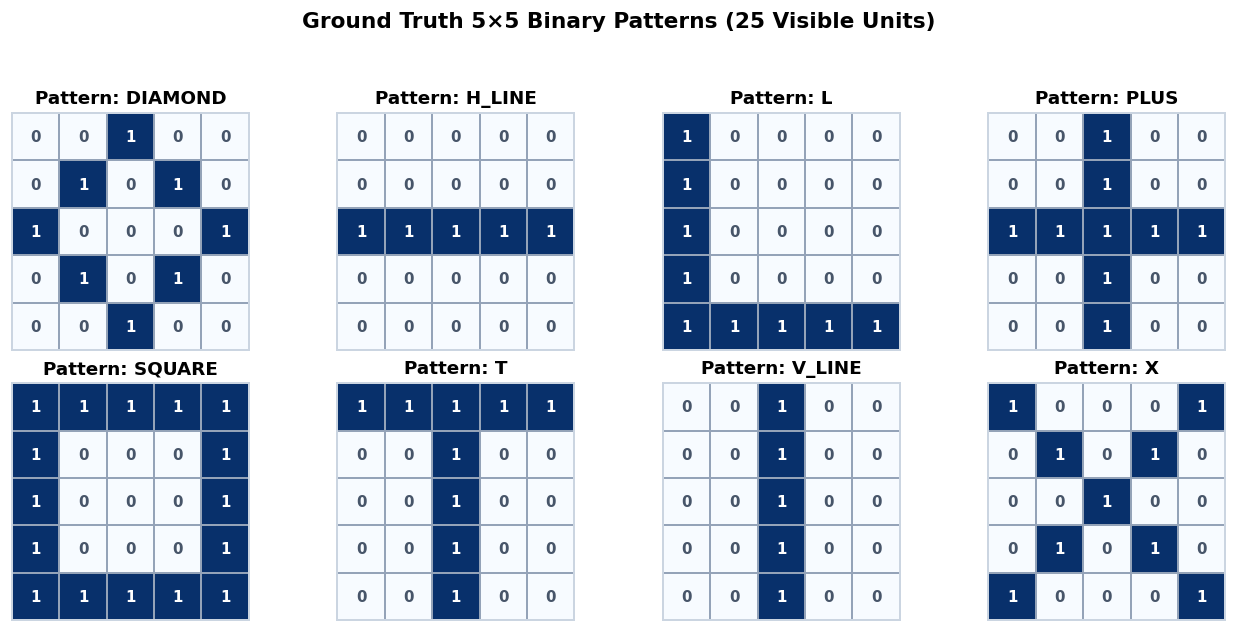

In [3]:
canonical_dict = {}
for pattern_name, group in df.groupby('pattern'):
    avg_pixels = group[pixel_cols].mean().values
    binary_proto = (avg_pixels >= 0.5).astype(np.float64)
    canonical_dict[pattern_name] = binary_proto

patterns = list(canonical_dict.keys())
fig, axes = plt.subplots(2, 4, figsize=(11, 5.5))
fig.suptitle("Ground Truth 5×5 Binary Patterns (25 Visible Units)", fontsize=13, fontweight='bold', y=0.98)

for idx, name in enumerate(patterns):
    ax = axes[idx // 4, idx % 4]
    grid = canonical_dict[name].reshape(5, 5)
    ax.imshow(grid, cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
    
    for r in range(5):
        for c in range(5):
            val = int(grid[r, c])
            color = 'white' if val == 1 else '#475569'
            ax.text(c, r, str(val), ha='center', va='center', fontsize=9, fontweight='bold', color=color)
            
    ax.set_title(f"Pattern: {name}", fontsize=11, fontweight='bold', pad=6)
    ax.set_xticks(np.arange(-0.5, 5, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 5, 1), minor=True)
    ax.grid(which='minor', color='#94a3b8', linestyle='-', linewidth=1.2)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()


## ⚙️ Step 4: Restricted Boltzmann Machine Implementation (From Scratch in NumPy)

Below is our complete, modular RBM class implementing the energy formulas, Gibbs sampling, and Contrastive Divergence with momentum and weight decay.


In [4]:
class RestrictedBoltzmannMachine:
    def __init__(self, n_visible=25, n_hidden=16, learning_rate=0.08, 
                 momentum=0.5, weight_decay=0.0001, random_state=42):
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.rng = np.random.RandomState(random_state)
        
        # Xavier-normal weight initialization
        self.W = self.rng.normal(0.0, 0.05, size=(n_visible, n_hidden))
        self.a = np.zeros(n_visible)  # Visible bias
        self.b = np.zeros(n_hidden)   # Hidden bias
        
        # Velocity buffers for momentum updates
        self.v_W = np.zeros_like(self.W)
        self.v_a = np.zeros_like(self.a)
        self.v_b = np.zeros_like(self.b)
        
        self.history = {
            'epoch': [],
            'mean_squared_error': [],
            'reconstruction_error': [],
            'free_energy': []
        }

    @staticmethod
    def sigmoid(z):
        z_clipped = np.clip(z, -30.0, 30.0)
        return 1.0 / (1.0 + np.exp(-z_clipped))

    def sample_bernoulli(self, probabilities):
        return (self.rng.rand(*probabilities.shape) < probabilities).astype(np.float64)

    def propagate_up(self, v):
        h_probs = self.sigmoid(np.dot(v, self.W) + self.b)
        h_states = self.sample_bernoulli(h_probs)
        return h_probs, h_states

    def propagate_down(self, h):
        v_probs = self.sigmoid(np.dot(h, self.W.T) + self.a)
        v_states = self.sample_bernoulli(v_probs)
        return v_probs, v_states

    def free_energy(self, v):
        v_bias_term = np.dot(v, self.a)
        wx_b = np.dot(v, self.W) + self.b
        hidden_term = np.sum(np.log1p(np.exp(np.clip(wx_b, -30.0, 30.0))), axis=-1)
        return -v_bias_term - hidden_term

    def contrastive_divergence(self, v_batch, k=1):
        batch_size = v_batch.shape[0]
        
        # Positive Phase
        h_probs_0, h_states_0 = self.propagate_up(v_batch)
        pos_associations = np.dot(v_batch.T, h_probs_0)
        
        # Negative Phase
        v_current = v_batch
        h_states = h_states_0
        for _ in range(k):
            v_probs_k, v_states_k = self.propagate_down(h_states)
            h_probs_k, h_states_k = self.propagate_up(v_probs_k)
            h_states = h_states_k
            v_current = v_probs_k
        
        neg_associations = np.dot(v_current.T, h_probs_k)
        
        # Gradients
        dW = (pos_associations - neg_associations) / batch_size - self.weight_decay * self.W
        da = np.mean(v_batch - v_current, axis=0)
        db = np.mean(h_probs_0 - h_probs_k, axis=0)
        
        # Momentum Updates
        self.v_W = self.momentum * self.v_W + self.learning_rate * dW
        self.v_a = self.momentum * self.v_a + self.learning_rate * da
        self.v_b = self.momentum * self.v_b + self.learning_rate * db
        
        self.W += self.v_W
        self.a += self.v_a
        self.b += self.v_b
        
        return np.mean((v_batch - v_current) ** 2)

    def fit(self, X, n_epochs=150, batch_size=16, k=1, verbose=True):
        n_samples = X.shape[0]
        for epoch in range(1, n_epochs + 1):
            self.momentum = 0.90 if epoch > 25 else 0.50
            indices = self.rng.permutation(n_samples)
            X_shuffled = X[indices]
            
            for i in range(0, n_samples, batch_size):
                v_batch = X_shuffled[i:i + batch_size]
                self.contrastive_divergence(v_batch, k=k)
            
            recon_probs, _ = self.reconstruct(X, steps=1, return_probabilities=True)
            epoch_mse = np.mean((X - recon_probs) ** 2)
            epoch_bce = -np.mean(X * np.log(np.clip(recon_probs, 1e-10, 1.0)) + 
                                 (1.0 - X) * np.log(np.clip(1.0 - recon_probs, 1e-10, 1.0)))
            avg_fe = np.mean(self.free_energy(X))
            
            self.history['epoch'].append(epoch)
            self.history['mean_squared_error'].append(epoch_mse)
            self.history['reconstruction_error'].append(epoch_bce)
            self.history['free_energy'].append(avg_fe)
            
            if verbose and (epoch % 30 == 0 or epoch == 1 or epoch == n_epochs):
                print(f"Epoch [{epoch:3d}/{n_epochs:3d}] | MSE: {epoch_mse:.5f} | Recon Loss (BCE): {epoch_bce:.4f} | Free Energy: {avg_fe:.2f}")
        return self.history

    def reconstruct(self, v, steps=1, return_probabilities=True):
        v_curr = np.copy(v)
        for _ in range(steps):
            h_probs, _ = self.propagate_up(v_curr)
            v_probs, _ = self.propagate_down(h_probs)
            v_curr = v_probs
        
        binary_output = (v_probs >= 0.5).astype(np.float64)
        if return_probabilities:
            return v_probs, binary_output
        return binary_output


## 🏋️ Step 5: Training the RBM via Contrastive Divergence (CD-1)

In [5]:
rbm = RestrictedBoltzmannMachine(
    n_visible=25,
    n_hidden=16,
    learning_rate=0.08,
    momentum=0.5,
    weight_decay=0.0001,
    random_state=42
)

history = rbm.fit(X, n_epochs=150, batch_size=16, k=1, verbose=True)


Epoch [  1/150] | MSE: 0.20634 | Recon Loss (BCE): 0.5982 | Free Energy: -8.11
Epoch [ 30/150] | MSE: 0.05958 | Recon Loss (BCE): 0.2125 | Free Energy: -29.67
Epoch [ 60/150] | MSE: 0.03820 | Recon Loss (BCE): 0.1355 | Free Energy: -44.06


Epoch [ 90/150] | MSE: 0.03275 | Recon Loss (BCE): 0.1170 | Free Energy: -50.30
Epoch [120/150] | MSE: 0.03008 | Recon Loss (BCE): 0.1085 | Free Energy: -56.88
Epoch [150/150] | MSE: 0.02874 | Recon Loss (BCE): 0.1026 | Free Energy: -61.12


## 📈 Step 6: Training Convergence & Free Energy Minimization

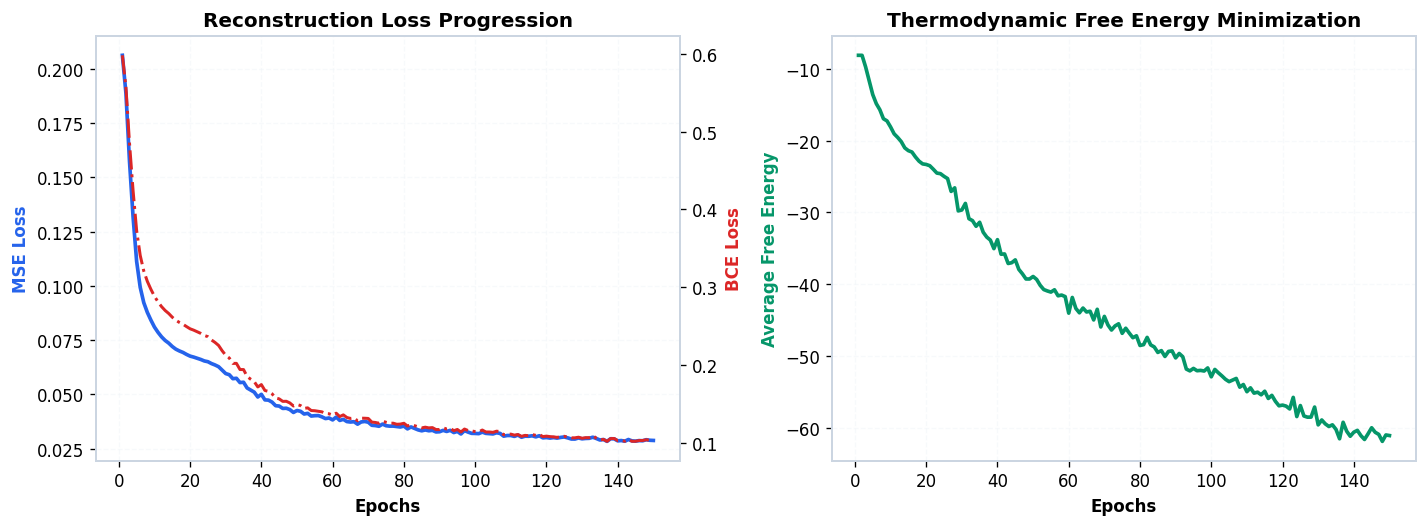

In [6]:
epochs = history['epoch']
mse = history['mean_squared_error']
bce = history['reconstruction_error']
fe = history['free_energy']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Subplot 1: MSE and BCE
ax1.plot(epochs, mse, color='#2563eb', lw=2.2, label='Mean Squared Error (MSE)')
ax1.set_xlabel('Epochs', fontweight='bold')
ax1.set_ylabel('MSE Loss', color='#2563eb', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

ax1_t = ax1.twinx()
ax1_t.plot(epochs, bce, color='#dc2626', lw=1.8, linestyle='-.', label='Cross-Entropy (BCE)')
ax1_t.set_ylabel('BCE Loss', color='#dc2626', fontweight='bold')
ax1.set_title("Reconstruction Loss Progression", fontweight='bold')

# Subplot 2: Free Energy
ax2.plot(epochs, fe, color='#059669', lw=2.2, label='Free Energy F(v)')
ax2.set_xlabel('Epochs', fontweight='bold')
ax2.set_ylabel('Average Free Energy', color='#059669', fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_title("Thermodynamic Free Energy Minimization", fontweight='bold')

plt.tight_layout()
plt.show()


## 🌪️ Step 7: Noise Generation (Corrupted Input Patterns)

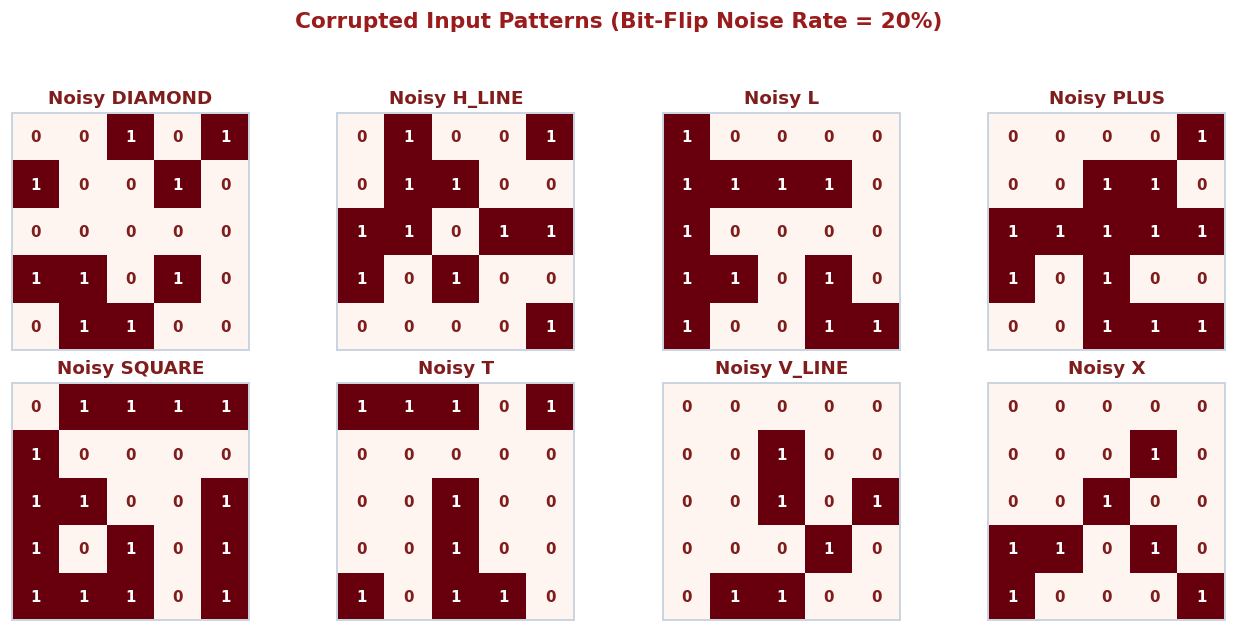

In [7]:
def add_noise(X, noise_rate=0.20, seed=42):
    rng = np.random.RandomState(seed)
    X_noisy = np.copy(X)
    flip_mask = rng.rand(*X.shape) < noise_rate
    X_noisy[flip_mask] = 1.0 - X_noisy[flip_mask]
    return X_noisy

canonical_X = np.array([canonical_dict[p] for p in canonical_dict.keys()])
noisy_canonical_X = add_noise(canonical_X, noise_rate=0.20, seed=42)

noisy_dict = {p: noisy_canonical_X[idx] for idx, p in enumerate(canonical_dict.keys())}

fig, axes = plt.subplots(2, 4, figsize=(11, 5.5))
fig.suptitle("Corrupted Input Patterns (Bit-Flip Noise Rate = 20%)", fontsize=13, fontweight='bold', y=0.98, color='#991b1b')

for idx, name in enumerate(patterns):
    ax = axes[idx // 4, idx % 4]
    grid = noisy_dict[name].reshape(5, 5)
    ax.imshow(grid, cmap='Reds', vmin=0, vmax=1, interpolation='nearest')
    for r in range(5):
        for c in range(5):
            val = int(grid[r, c])
            color = 'white' if val == 1 else '#7f1d1d'
            ax.text(c, r, str(val), ha='center', va='center', fontsize=9, fontweight='bold', color=color)
    ax.set_title(f"Noisy {name}", fontsize=11, fontweight='bold', pad=6, color='#7f1d1d')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()


## 🎯 Step 8: Associative Memory Pattern Restoration (Denoising)

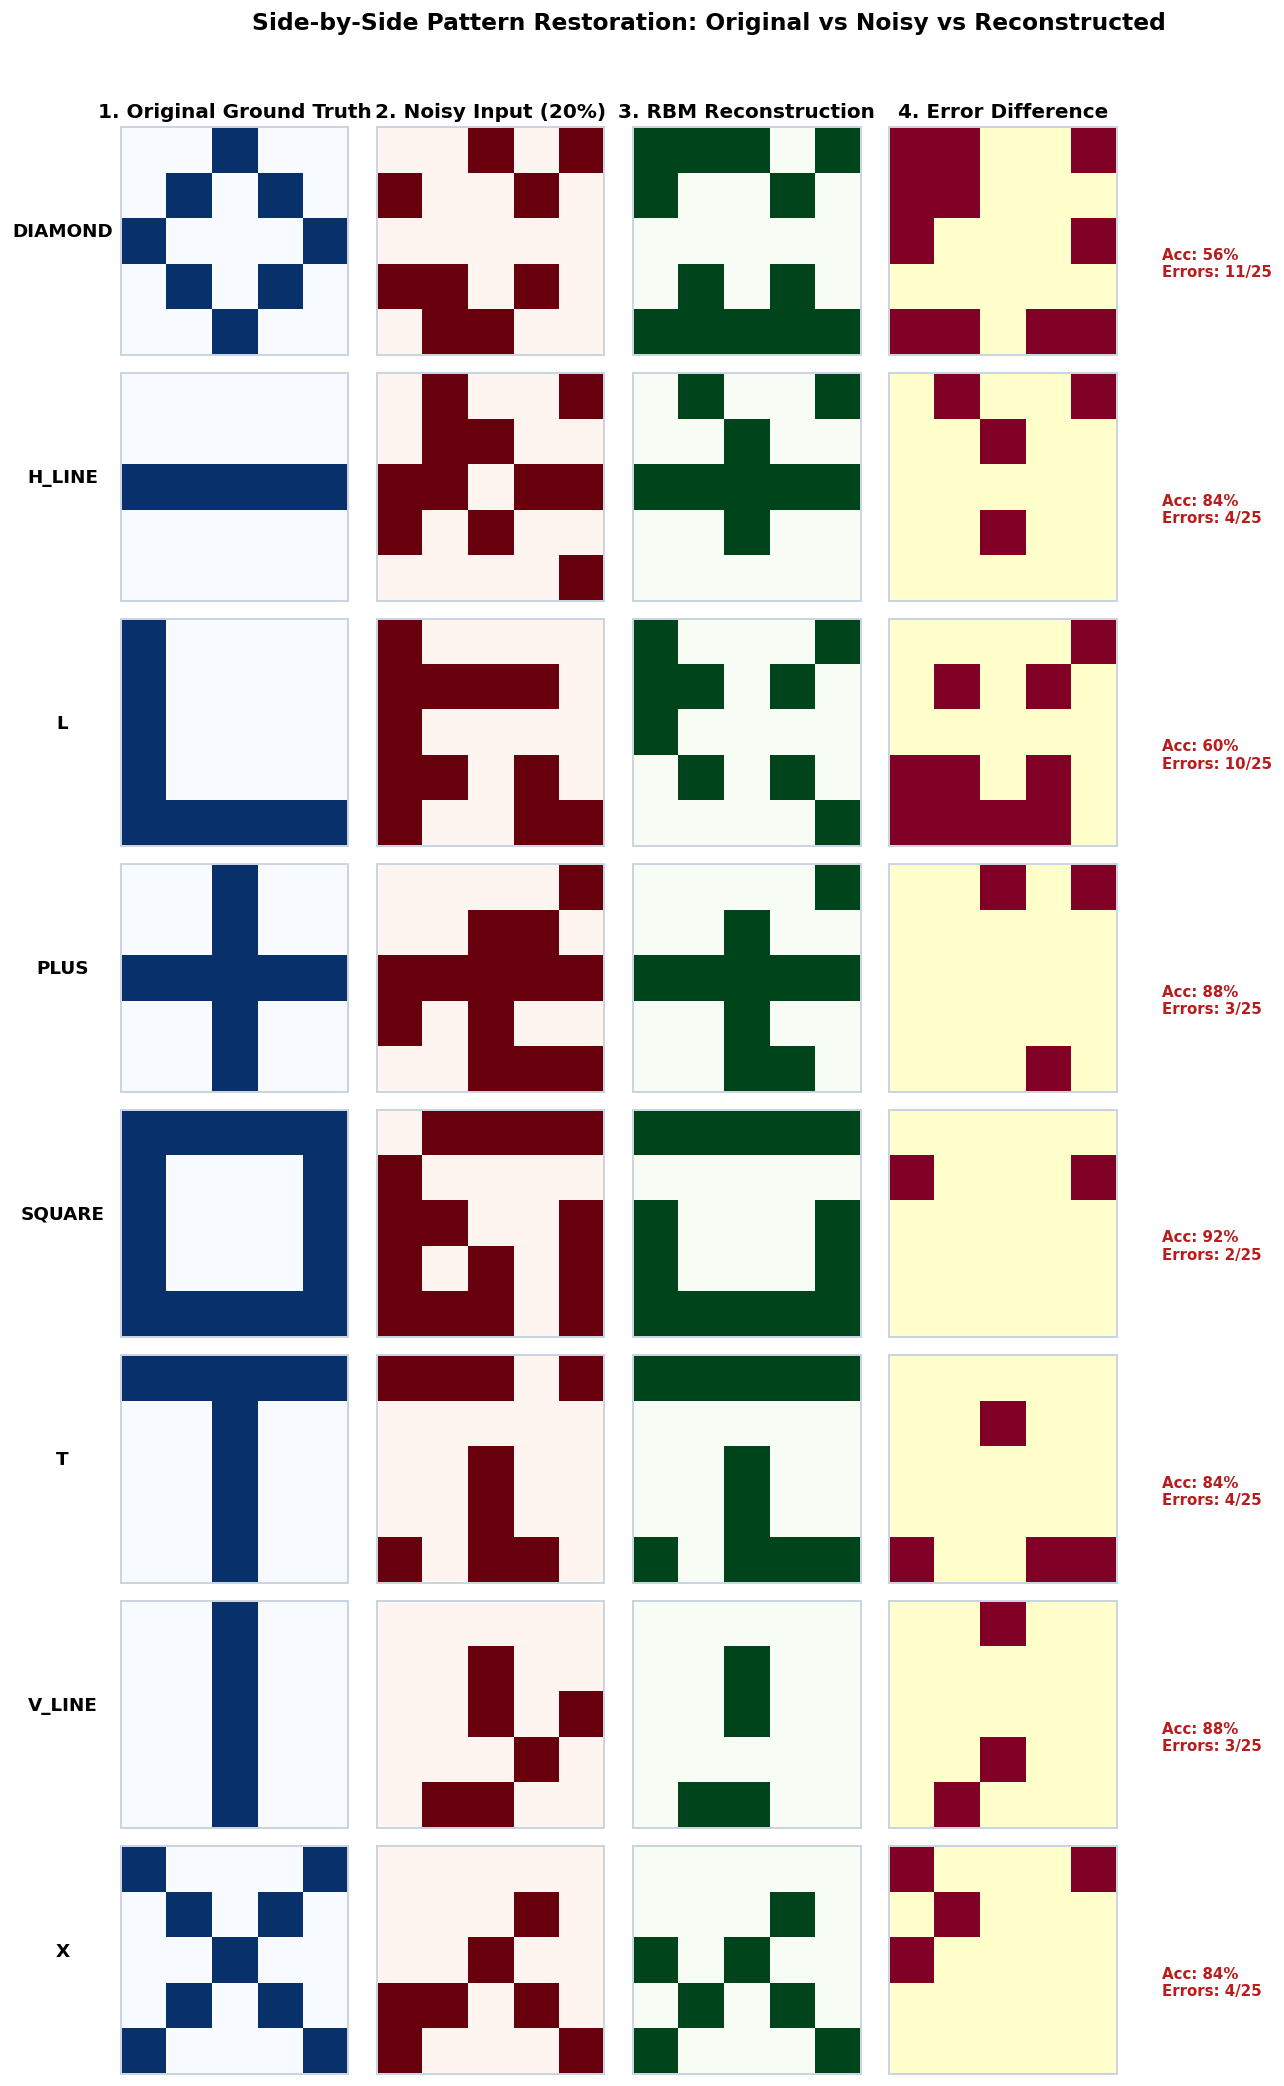

In [8]:
recon_probs, recon_binary = rbm.reconstruct(noisy_canonical_X, steps=1, return_probabilities=True)
recon_dict = {p: recon_binary[idx] for idx, p in enumerate(canonical_dict.keys())}

fig, axes = plt.subplots(len(patterns), 4, figsize=(12, 2.2 * len(patterns)))
fig.suptitle("Side-by-Side Pattern Restoration: Original vs Noisy vs Reconstructed", fontsize=14, fontweight='bold', y=0.995)

for idx, name in enumerate(patterns):
    orig = canonical_dict[name].reshape(5, 5)
    noisy = noisy_dict[name].reshape(5, 5)
    recon = recon_dict[name].reshape(5, 5)
    diff = np.abs(orig - recon)
    
    acc = np.mean(orig == recon) * 100
    hamming = int(np.sum(orig != recon))
    
    axes[idx, 0].imshow(orig, cmap='Blues', vmin=0, vmax=1)
    axes[idx, 0].set_ylabel(name, fontweight='bold', fontsize=11, rotation=0, labelpad=35)
    
    axes[idx, 1].imshow(noisy, cmap='Reds', vmin=0, vmax=1)
    axes[idx, 2].imshow(recon, cmap='Greens', vmin=0, vmax=1)
    axes[idx, 3].imshow(diff, cmap='YlOrRd', vmin=0, vmax=1)
    
    axes[idx, 3].text(5.5, 2.5, f"Acc: {acc:.0f}%\nErrors: {hamming}/25", fontsize=9, fontweight='bold',
                      color='#065f46' if hamming == 0 else '#b91c1c', va='center')
    
    for ax in axes[idx]:
        ax.set_xticks([])
        ax.set_yticks([])

axes[0, 0].set_title("1. Original Ground Truth", fontweight='bold')
axes[0, 1].set_title("2. Noisy Input (20%)", fontweight='bold')
axes[0, 2].set_title("3. RBM Reconstruction", fontweight='bold')
axes[0, 3].set_title("4. Error Difference", fontweight='bold')

plt.tight_layout(rect=[0, 0.01, 0.90, 0.98])
plt.show()


## 📋 Step 9: Quantitative Evaluation & Metric Calculations

In [9]:
metrics = []
for idx, p in enumerate(patterns):
    orig = canonical_X[idx]
    noisy = noisy_canonical_X[idx]
    recon = recon_binary[idx]
    
    noisy_acc = np.mean(orig == noisy) * 100.0
    recon_acc = np.mean(orig == recon) * 100.0
    noisy_hamm = int(np.sum(orig != noisy))
    recon_hamm = int(np.sum(orig != recon))
    mse_val = np.mean((orig - recon) ** 2)
    ber = np.mean(orig != recon)
    gain = recon_acc - noisy_acc
    
    metrics.append({
        'Pattern': p,
        'Noisy Acc (%)': noisy_acc,
        'Recon Acc (%)': recon_acc,
        'Noisy Hamming': f"{noisy_hamm}/25",
        'Recon Hamming': f"{recon_hamm}/25",
        'MSE': round(mse_val, 4),
        'Bit Error Rate': round(ber, 4),
        'Recovery Gain (%)': f"+{gain:.1f}%" if gain >= 0 else f"{gain:.1f}%"
    })

metrics_df = pd.DataFrame(metrics)
display(metrics_df)


,Pattern,Noisy Acc (%),Recon Acc (%),Noisy Hamming,Recon Hamming,MSE,Bit Error Rate,Recovery Gain (%)
0,DIAMOND,72.0,56.0,7/25,11/25,0.44,0.44,-16.0%
1,H_LINE,68.0,84.0,8/25,4/25,0.16,0.16,+16.0%
2,L,72.0,60.0,7/25,10/25,0.40,0.40,-12.0%
3,PLUS,76.0,88.0,6/25,3/25,0.12,0.12,+12.0%
4,SQUARE,80.0,92.0,5/25,2/25,0.08,0.08,+12.0%
5,T,84.0,84.0,4/25,4/25,0.16,0.16,+0.0%
6,V_LINE,80.0,88.0,5/25,3/25,0.12,0.12,+8.0%
7,X,84.0,84.0,4/25,4/25,0.16,0.16,+0.0%


## 🔬 Step 10: Feature Interpretability — Visualizing Learned Weight Receptive Fields

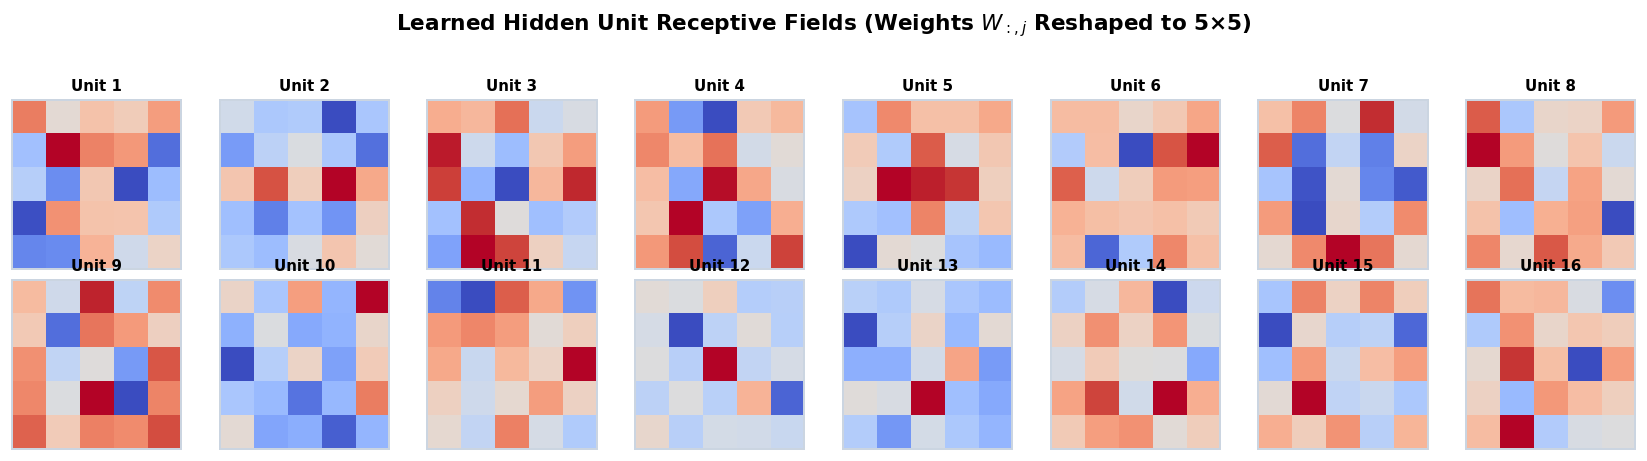

In [10]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle("Learned Hidden Unit Receptive Fields (Weights $W_{:, j}$ Reshaped to 5×5)", fontsize=13, fontweight='bold', y=0.98)

for h in range(16):
    ax = axes[h // 8, h % 8]
    w_patch = rbm.W[:, h].reshape(5, 5)
    im = ax.imshow(w_patch, cmap='coolwarm', interpolation='nearest')
    ax.set_title(f"Unit {h+1}", fontsize=9, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()


## 🧪 Step 11: Noise Robustness Analysis (0% to 50% Noise Injection)

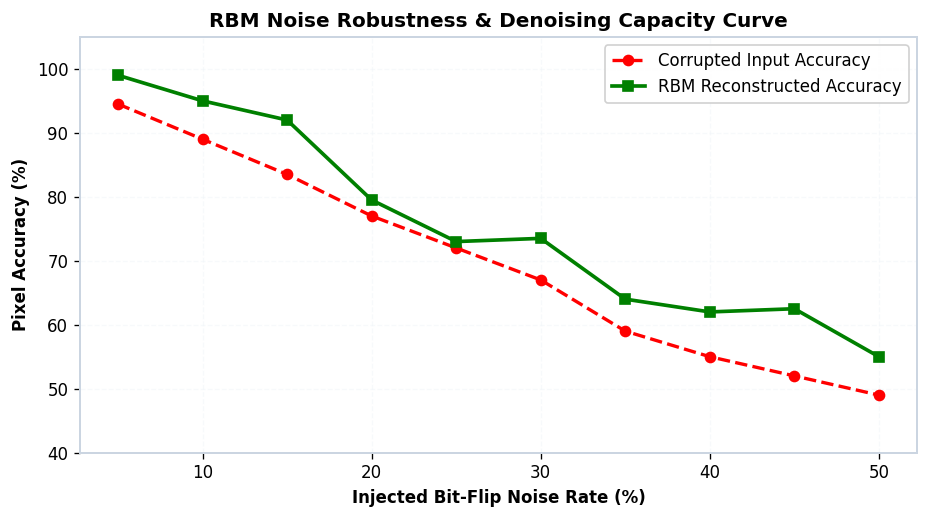

In [11]:
noise_rates = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
input_accs = []
output_accs = []

for nr in noise_rates:
    noisy_test = add_noise(canonical_X, noise_rate=nr, seed=42)
    _, recon_test = rbm.reconstruct(noisy_test, steps=1, return_probabilities=True)
    
    in_acc = np.mean(canonical_X == noisy_test) * 100
    out_acc = np.mean(canonical_X == recon_test) * 100
    input_accs.append(in_acc)
    output_accs.append(out_acc)

plt.figure(figsize=(9, 4.5))
plt.plot([nr * 100 for nr in noise_rates], input_accs, 'r--o', lw=2, label='Corrupted Input Accuracy')
plt.plot([nr * 100 for nr in noise_rates], output_accs, 'g-s', lw=2.2, label='RBM Reconstructed Accuracy')
plt.xlabel('Injected Bit-Flip Noise Rate (%)', fontweight='bold')
plt.ylabel('Pixel Accuracy (%)', fontweight='bold')
plt.title('RBM Noise Robustness & Denoising Capacity Curve', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(framealpha=0.9)
plt.ylim(40, 105)
plt.show()


## 🎓 Step 12: Viva Voce & Academic Q&A Preparation

### Key Viva Questions & Answers:

1. **Q: What is the primary difference between a Standard Boltzmann Machine and a Restricted Boltzmann Machine?**
   * **A:** A Standard Boltzmann Machine has all-to-all connectivity including intra-layer connections (visible-to-visible and hidden-to-hidden), making exact Gibbs sampling slow and intractable. An RBM restricts connections to be bipartite (only visible-to-hidden), creating conditional independence: $P(h|v) = \prod P(h_j|v)$ and $P(v|h) = \prod P(v_i|h)$, enabling parallel block Gibbs sampling.

2. **Q: Why do we use Contrastive Divergence (CD-1) instead of Maximum Likelihood estimation?**
   * **A:** The exact gradient of log-likelihood requires calculating the expectation over the full Boltzmann distribution (partition function $Z$), which requires $2^{25}$ sums. CD-1 approximates this by running only 1 step of Gibbs sampling initialized from the data distribution, yielding fast and accurate gradient estimates.

3. **Q: How does the RBM perform pattern denoising / associative memory recall?**
   * **A:** During training, the RBM adjusts its weights $W$ and biases $a, b$ so that the energy $E(v, h)$ is minimized at the points corresponding to the training patterns. When presented with a noisy pattern, Gibbs sampling updates the visible state toward the nearest local minimum (energy basin of attraction), recovering the original binary pattern.

4. **Q: Why are weights symmetric in an RBM ($W_{ij} = W_{ji}$)?**
   * **A:** Symmetric weights guarantee that an energy function exists and is well-defined. If weights were asymmetric, the state updates would not correspond to gradient descent on an energy surface.
